# DTSC - 691: Machine Learning Project
## Stock price prediction
## Bright Ofori

## Overview

The stock price prediction project aims to leverage historical stock market data to develop a predictive model capable of forecasting future stock prices. The model will utilize a core dataset that captures critical daily metrics of stock performance. These features are essential for analyzing market trends, identifying patterns, and building a robust time-series predictive framework.

Core Dataset Features:
Date: This feature represents the specific trading date, maintaining the chronological structure crucial for time-series analysis.
Open: The stock price at the beginning of the trading session, providing insight into market sentiment at the start of the day.
Close: The final trading price of the stock or index (e.g., NASDAQ-100) at the end of the trading day, reflecting the overall sentiment and trading activity for that day.
High: The maximum price reached during the trading session, indicating the peak performance level for the day.
Low: The minimum price recorded during the trading session, capturing the day's lowest trading value.

This dataset is central to training and testing machine learning models, as it provides the foundational input for generating predictions. By utilizing historical trends and integrating advanced algorithms, the project aims to achieve accurate and reliable stock price forecasts, aiding investors in decision-making and strategic planning.

## Steps

1. Exploratory Data analysis
2. Data preparation and cleaning 
3. Model training and evaluation

# Exploratory Data analysis:
This is a crucial step in understanding the dataset and uncovering patterns, trends,
potential anomalies and relationships within the data.

In [168]:
#pip install yfinance

In [169]:
from numpy.random import seed
seed(1)
from tensorflow import random
random.set_seed(1)

In [170]:
# common imports
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [171]:
#Import datetime to help manipulate date and time
from datetime import datetime
end = datetime.now()
start = datetime(end.year-10, end.month, end.day)

In [172]:
# Import the nasdaq-100 dataset
df = pd.read_csv("nasdaq_historical_data.csv")
df.head()


,Date,Close/Last,Open,High,Low
0,07/05/2024,20391.97,20224.13,20406.99,20201.50
1,07/03/2024,20186.63,19995.28,20186.63,19995.28
2,07/02/2024,20011.89,19746.22,20014.92,19741.81
3,07/01/2024,19812.22,19720.11,19827.75,19577.54
4,06/28/2024,19682.87,19817.00,20017.71,19665.85


#### Set up the column headers to match preferred headers on yahoo finance

In [173]:
#Set up headers
nasdaq = pd.DataFrame(df)

# Define the MultiIndex header
header = [
    ["Price", "Close", "High", "Low", "Open"], 
    ["Ticker", "NDX", "NDX", "NDX", "NDX"],
    ["Date", "", "", "", "",]
]

# Create the MultiIndex
multi_index = pd.MultiIndex.from_arrays(header)

# Assign MultiIndex to columns
nasdaq.columns = multi_index

# Final DataFrame
nasdaq


,Price,Close,High,Low,Open
,Ticker,NDX,NDX,NDX,NDX
,Date,,,,
0,07/05/2024,20391.97,20224.13,20406.99,20201.50
1,07/03/2024,20186.63,19995.28,20186.63,19995.28
2,07/02/2024,20011.89,19746.22,20014.92,19741.81
3,07/01/2024,19812.22,19720.11,19827.75,19577.54
4,06/28/2024,19682.87,19817.00,20017.71,19665.85
...,...,...,...,...,...
2523,07/14/2014,3929.46,3923.60,3937.73,3916.52
2524,07/11/2014,3904.58,3888.76,3905.40,3879.40


In [174]:
# Check the structure of the MultiIndex
print(nasdaq.columns) 
print(nasdaq.index)    

# Display the levels of the MultiIndex
print(nasdaq.columns.names)  
print(nasdaq.columns.levels)  


MultiIndex([('Price', 'Ticker', 'Date'),
            ('Close',    'NDX',     ''),
            ( 'High',    'NDX',     ''),
            (  'Low',    'NDX',     ''),
            ( 'Open',    'NDX',     '')],
           )
RangeIndex(start=0, stop=2528, step=1)
[None, None, None]
[['Close', 'High', 'Low', 'Open', 'Price'], ['NDX', 'Ticker'], ['', 'Date']]


In [175]:
#Check the shape of dataset
nasdaq.shape

(2528, 5)

In [176]:
#Check for null or missing values
nasdaq.isna().sum()

Price  Ticker  Date    0
Close  NDX             0
High   NDX             0
Low    NDX             0
Open   NDX             0
dtype: int64

In [177]:
nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2528 entries, 0 to 2527
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Price, Ticker, Date)  2528 non-null   object 
 1   (Close, NDX, )         2528 non-null   float64
 2   (High, NDX, )          2528 non-null   float64
 3   (Low, NDX, )           2528 non-null   float64
 4   (Open, NDX, )          2528 non-null   float64
dtypes: float64(4), object(1)
memory usage: 98.9+ KB


In [178]:
#Summary of statistical characteristics
nasdaq.describe()

,Close,High,Low,Open
,NDX,NDX,NDX,NDX
,,,,
count,2528.000000,2528.000000,2528.000000,2528.000000
mean,9204.763975,9181.056582,9246.720827,9111.935922
std,4385.330472,4416.516349,4449.784563,4381.278041
min,3765.280000,0.000000,0.000000,0.000000
25%,4925.022500,4925.000000,4947.455000,4909.165000
50%,7629.345000,7631.085000,7681.910000,7583.845000
75%,12997.597500,12986.682500,13098.195000,12886.502500
max,20391.970000,20224.130000,20406.990000,20201.500000


In [179]:
# Function to clean unwanted characters from strings
def clean_value(value):
    if isinstance(value, str):
        value = unicodedata.normalize('NFKD', value)
        value = re.sub(r'[^\w\.\-]', '', value)
        value = value.strip()
    return value

In [180]:
#Flatten column names for easy reference
nasdaq.columns = ['_'.join(filter(None, map(str, col))) for col in nasdaq.columns]
nasdaq

,Price_Ticker_Date,Close_NDX,High_NDX,Low_NDX,Open_NDX
0,07/05/2024,20391.97,20224.13,20406.99,20201.50
1,07/03/2024,20186.63,19995.28,20186.63,19995.28
2,07/02/2024,20011.89,19746.22,20014.92,19741.81
3,07/01/2024,19812.22,19720.11,19827.75,19577.54
4,06/28/2024,19682.87,19817.00,20017.71,19665.85
...,...,...,...,...,...
2523,07/14/2014,3929.46,3923.60,3937.73,3916.52
2524,07/11/2014,3904.58,3888.76,3905.40,3879.40
2525,07/10/2014,3880.04,3837.29,3895.72,3837.16
2526,07/09/2014,3892.91,3873.17,3896.38,3863.20


### visualize closing price over the years

In [181]:
%matplotlib inline

Text(0.5, 1.0, 'Closing price of Nasdaq-100 data')

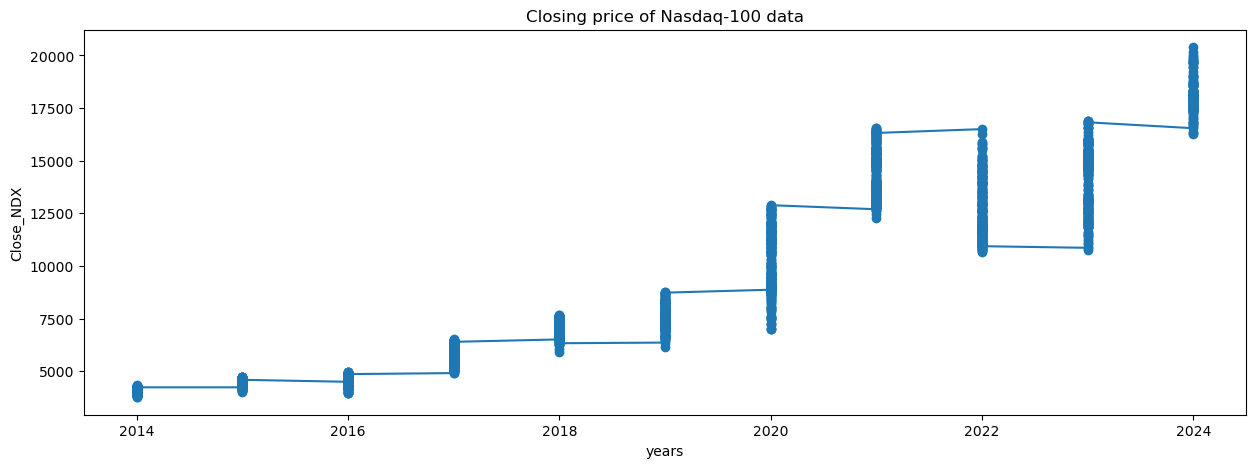

In [182]:
# Ensure the date column is in datetime format
nasdaq['Price_Ticker_Date'] = pd.to_datetime(nasdaq['Price_Ticker_Date'])

# Extract the year from the Date column
nasdaq['Year'] = nasdaq['Price_Ticker_Date'].dt.year

plt.figure(figsize = (15,5))
plt.plot(nasdaq['Year'], nasdaq['Close_NDX'], marker='o')
plt.xlabel("years")
plt.ylabel("Close_NDX")
plt.title("Closing price of Nasdaq-100 data")

### Line chart of closing price over time

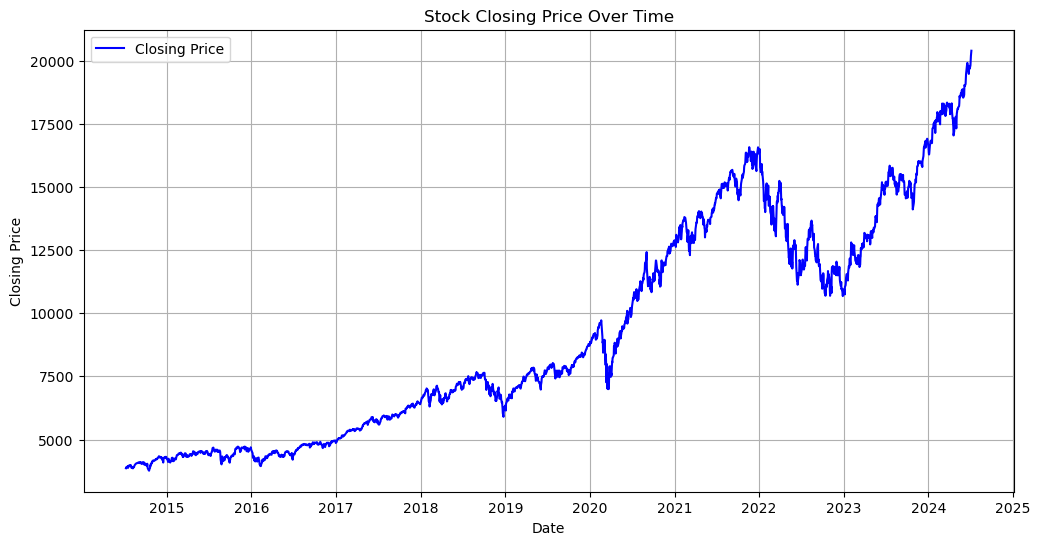

In [183]:
# Ensure the date column is in datetime format
nasdaq['Price_Ticker_Date'] = pd.to_datetime(nasdaq['Price_Ticker_Date'])

# Set the date as the index (optional, useful for time series data)
nasdaq.set_index('Price_Ticker_Date', inplace=True)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(nasdaq.index, nasdaq['Close_NDX'], color='blue', label='Closing Price')

# Add titles and labels
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()


### Visualize outlier in stock prices

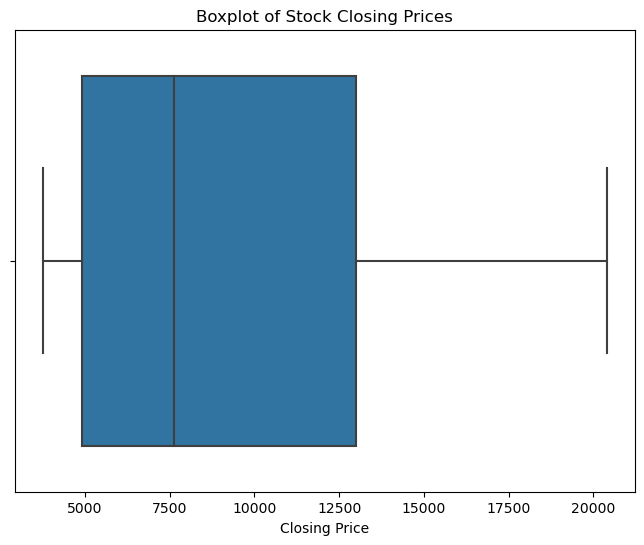

In [184]:
# Plot boxplot for the stock closing prices
plt.figure(figsize=(8, 6))
sns.boxplot(x=nasdaq['Close_NDX'], orient='h')
plt.title('Boxplot of Stock Closing Prices')
plt.xlabel('Closing Price')
plt.show()


In [185]:
#Check for outliers
# Calculate Q1, Q3, and IQR
Q1 = nasdaq['Close_NDX'].quantile(0.25)
Q3 = nasdaq['Close_NDX'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = nasdaq[(nasdaq['Close_NDX'] < lower_bound) | (nasdaq['Close_NDX'] > upper_bound)]

print("Outliers detected:")
print(outliers)


Outliers detected:
Empty DataFrame
Columns: [Close_NDX, High_NDX, Low_NDX, Open_NDX, Year]
Index: []


### Heatmap of daily returns over time

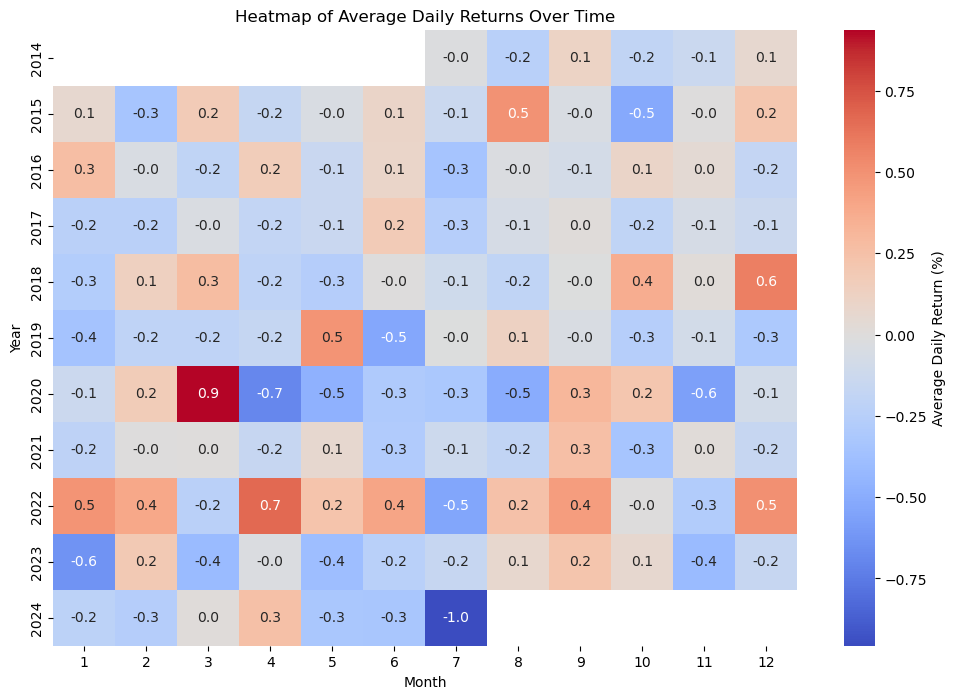

In [186]:
# Calculate daily returns
nasdaq['Daily Return'] = nasdaq['Close_NDX'].pct_change() * 100  

# Pivot data to create a matrix for heatmap
# Group by year and month
nasdaq['Year'] = nasdaq.index.year
nasdaq['Month'] = nasdaq.index.month

# Pivot the data to have months as columns and years as rows
heatmap_data = nasdaq.pivot_table(values='Daily Return', index='Year', columns='Month', aggfunc=np.mean)

# Plotting
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt=".1f", cbar_kws={'label': 'Average Daily Return (%)'})
plt.title("Heatmap of Average Daily Returns Over Time")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()


### Calculate moving averages over the years

In [187]:
#Function to see the number of trading days in each year
for i in range(2014, 2024):
    print(i,list(nasdaq.index.year).count(i))

2014 127
2015 261
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250


In [188]:
#Mean of 250 moving days
nasdaq['MA_for_250_days'] = nasdaq['Close_NDX'].rolling(250).mean()

In [189]:
nasdaq['MA_for_250_days'][0:250].tail()

Price_Ticker_Date
2023-07-14            NaN
2023-07-13            NaN
2023-07-12            NaN
2023-07-11            NaN
2023-07-10    16795.44576
Name: MA_for_250_days, dtype: float64

In [190]:
#Mean of 100 moving days
nasdaq['MA_for_100_days'] = nasdaq['Close_NDX'].rolling(100).mean()

In [191]:
#Function to plot moving averages
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize =figsize)
    plt.xlabel("years")
    plt.xlabel(column_name)
    plt.title(f"{column_name} of nasdaq data")

<Figure size 640x480 with 0 Axes>

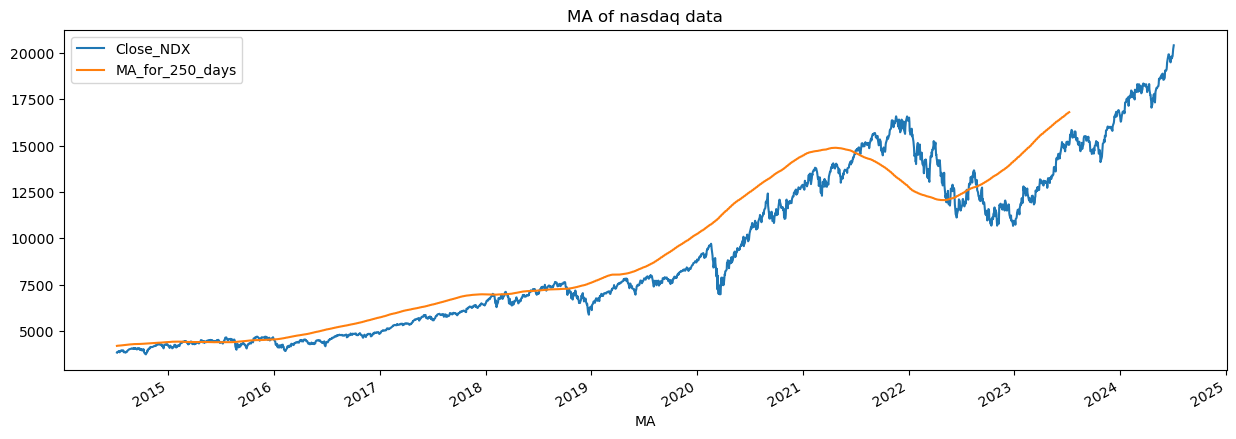

In [192]:
#Plot graph: Moving averages for 250 days
plot_graph((15,5), nasdaq[['Close_NDX','MA_for_250_days']], 'MA')

<Figure size 640x480 with 0 Axes>

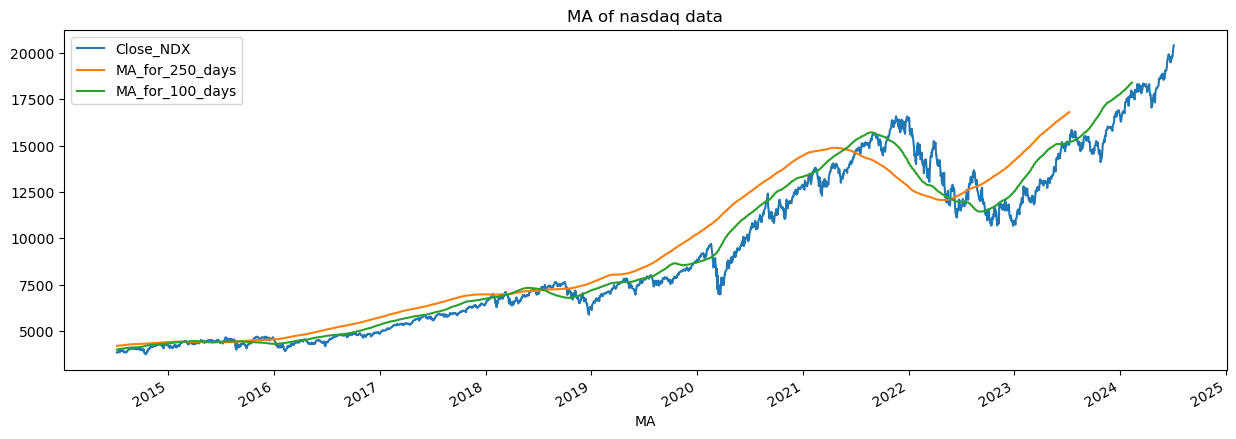

In [193]:
#Plot graph: Moving averages of 250 and 100 days
plot_graph((15,5), nasdaq[['Close_NDX','MA_for_250_days','MA_for_100_days']], 'MA')

### Percentage change in closing price

In [194]:
#Sort by date
nasdaq = nasdaq.sort_values(by='Price_Ticker_Date', ascending=True)

In [195]:
#Percentage change in closing price
nasdaq['percentage_change_cp'] = nasdaq['Close_NDX'].pct_change()
nasdaq[['Close_NDX','percentage_change_cp']].head()

,Close_NDX,percentage_change_cp
Price_Ticker_Date,,
2014-07-08,3864.07,NaN
2014-07-09,3892.91,0.007464
2014-07-10,3880.04,-0.003306
2014-07-11,3904.58,0.006325
2014-07-14,3929.46,0.006372


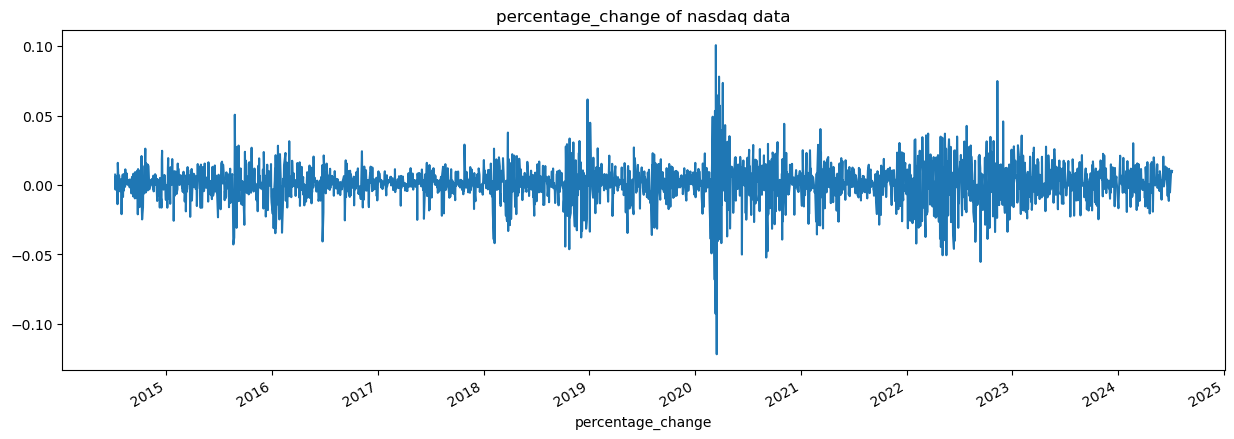

In [196]:
#Visualize percentage change
plot_graph((15,5), nasdaq['percentage_change_cp'],'percentage_change')

# Data Preparation 

In [197]:
#Settiing the closing price, max and min values
close_price = nasdaq[['Close_NDX']]

In [198]:
#checking for min and max closing price.
max(close_price.values), min(close_price.values)

(array([20391.97]), array([3765.28]))

In [199]:
#Scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_price)
scaled_data

array([[0.00594165],
       [0.00767621],
       [0.00690216],
       ...,
       [0.97714037],
       [0.98764998],
       [1.        ]])

In [200]:
#Function to preprocess data for Long short-Term Memory (LSTM)
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

#Convert from python lists to NumPy arrrays for efficient computation
x_data, y_data = np.array(x_data), np.array(y_data)

In [201]:
x_data[0], y_data[0]

(array([[0.00594165],
        [0.00767621],
        [0.00690216],
        [0.0083781 ],
        [0.00987448],
        [0.00897172],
        [0.0100471 ],
        [0.00678006],
        [0.01050179],
        [0.01015596],
        [0.01180872],
        [0.01328647],
        [0.01310604],
        [0.01202164],
        [0.01214674],
        [0.01165295],
        [0.01267781],
        [0.00765155],
        [0.0068799 ],
        [0.0086301 ],
        [0.00659542],
        [0.00655512],
        [0.00557297],
        [0.00738632],
        [0.00873174],
        [0.00841659],
        [0.01106173],
        [0.0122592 ],
        [0.01336586],
        [0.01535002],
        [0.01653065],
        [0.01656493],
        [0.01694565],
        [0.01728967],
        [0.0181756 ],
        [0.0184276 ],
        [0.01851842],
        [0.01810282],
        [0.01908257],
        [0.01908257],
        [0.01987948],
        [0.0183849 ],
        [0.0180944 ],
        [0.01952523],
        [0.01985843],
        [0

In [202]:
#80% of X_data
int(len(x_data)*0.8)
len(x_data)
2428-100-int(len(x_data)*0.8)

386

In [203]:
#Splitting dataset into train and test split
len_split = int(len(x_data)*0.8)
x_train = x_data[:len_split]
y_train = y_data[:len_split]

x_test = x_data[len_split:]
y_test = y_data[len_split:]

In [204]:
#Shape of train and test data
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1942, 100, 1)
(1942, 1)
(486, 100, 1)
(486, 1)


### Train the model

In [205]:
#Create LSTM model
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.metrics import mean_squared_error

model =Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

In [206]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [207]:
model.fit(x_train, y_train, validation_data = (x_test, y_test), batch_size=100, epochs = 10, verbose=1)

Epoch 1/10
20/20 [==============================] - 15s 504ms/step - loss: 0.0138 - val_loss: 0.0049
Epoch 2/10
20/20 [==============================] - 7s 377ms/step - loss: 9.4421e-04 - val_loss: 6.9566e-04
Epoch 3/10
20/20 [==============================] - 7s 348ms/step - loss: 3.1041e-04 - val_loss: 9.2781e-04
Epoch 4/10
20/20 [==============================] - 7s 334ms/step - loss: 2.4391e-04 - val_loss: 5.0090e-04
Epoch 5/10
20/20 [==============================] - 7s 343ms/step - loss: 2.3891e-04 - val_loss: 6.2528e-04
Epoch 6/10
20/20 [==============================] - 7s 362ms/step - loss: 2.2995e-04 - val_loss: 5.5056e-04
Epoch 7/10
20/20 [==============================] - 7s 332ms/step - loss: 2.3671e-04 - val_loss: 5.2510e-04
Epoch 8/10
20/20 [==============================] - 7s 332ms/step - loss: 2.5435e-04 - val_loss: 0.0010
Epoch 9/10
20/20 [==============================] - 7s 339ms/step - loss: 2.5714e-04 - val_loss: 4.9865e-04
Epoch 10/10
20/20 [====================

In [208]:
model.summary()

Model: "sequential_733"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_735 (LSTM)             (None, 100, 128)          66560     
                                                                 
 lstm_736 (LSTM)             (None, 64)                49408     
                                                                 
 dense_735 (Dense)           (None, 25)                1625      
                                                                 
 dense_736 (Dense)           (None, 1)                 26        
                                                                 
Total params: 117,619
Trainable params: 117,619
Non-trainable params: 0
_________________________________________________________________


In [209]:
#Evaluate and predict
loss = model.evaluate(x_test, y_test)
print(f'Loss: {loss}')

16/16 [==============================] - 1s 56ms/step - loss: 4.7488e-04
Loss: 0.00047488484415225685


In [210]:
#Predictions
predictions = model.predict(x_test)

16/16 [==============================] - 2s 55ms/step


In [211]:
#transfrom scaled predictions
predicted = scaler.inverse_transform(predictions)


In [212]:
#transform scaled actual values
actual = scaler.inverse_transform(y_test)


### Evaluate the Model

In [213]:
#Calculate RMSE
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(actual, predicted, squared=False)
print(f"RMSE: {rmse}")

RMSE: 362.32638365868644


### Perform a grid search

In [214]:
# # Second training
# import numpy as np
# from sklearn.model_selection import GridSearchCV
# from keras.models import Sequential
# from keras.layers import LSTM, Dense, Dropout
# from keras.wrappers.scikit_learn import KerasRegressor
# from keras.optimizers import Adam

# # Define the model directly in GridSearchCV
# def build_lstm(units, dropout_rate, learning_rate):
#     model1 = Sequential()
#     model1.add(LSTM(units=units, input_shape=(x_train.shape[1], x_train.shape[2]), return_sequences=False))
#     model1.add(Dropout(dropout_rate))
#     model1.add(Dense(1))  # Single output for regression
#     optimizer = Adam(learning_rate=learning_rate)
#     model1.compile(optimizer=optimizer, loss='mean_squared_error')
#     return model1

# # Wrap the model for GridSearchCV compatibility
# model1 = KerasRegressor(build_fn=build_lstm, verbose=0)

# # Define the grid of parameters
# param_grid = {
#     'units': [50, 100, 150],               # LSTM units
#     'dropout_rate': [0.1, 0.2, 0.3],       # Dropout rates
#     'learning_rate': [0.001, 0.01, 0.1],   # Learning rates
#     'batch_size': [16, 32, 64],           # Batch sizes
#     'epochs': [10, 20, 50],               # Number of epochs
# }

# # Perform GridSearchCV
# grid = GridSearchCV(estimator=model1, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
# grid_result = grid.fit(x_train, y_train)

# # Print best parameters and best score
# print(f"Best Parameters: {grid_result.best_params_}")
# print(f"Best Score (negative MSE): {grid_result.best_score_}")


In [215]:
from keras.layers import Dropout
from keras.optimizers import Adam

# Define the best parameters from GridSearchCV
best_params = {
    'units': 50,
    'dropout_rate': 0.2,
    'learning_rate': 0.01,
    'batch_size': 16,
    'epochs': 20
}

# Build the LSTM model
model_GSCV = Sequential()
model_GSCV.add(LSTM(units=best_params['units'], input_shape=(x_train.shape[1], x_train.shape[2]), return_sequences=False))
model_GSCV.add(Dropout(best_params['dropout_rate']))
model_GSCV.add(Dense(1))  

# Compile the model
optimizer = Adam(learning_rate=best_params['learning_rate'])
model_GSCV.compile(optimizer=optimizer, loss='mean_squared_error')

# Train the model
model_GSCV.fit(x_train, y_train, batch_size=best_params['batch_size'], epochs=best_params['epochs'], verbose=1, validation_split=0.2)

# Evaluate the model on test data
test_loss = model_GSCV.evaluate(x_test, y_test, verbose=1)
print(f"Test Loss (MSE): {test_loss}")


Epoch 1/20
98/98 [==============================] - 7s 49ms/step - loss: 0.0015 - val_loss: 6.6029e-04
Epoch 2/20
98/98 [==============================] - 4s 43ms/step - loss: 3.9362e-04 - val_loss: 0.0013
Epoch 3/20
98/98 [==============================] - 4s 45ms/step - loss: 3.2088e-04 - val_loss: 7.7873e-04
Epoch 4/20
98/98 [==============================] - 4s 42ms/step - loss: 3.0074e-04 - val_loss: 6.0368e-04
Epoch 5/20
98/98 [==============================] - 4s 41ms/step - loss: 2.3105e-04 - val_loss: 0.0013
Epoch 6/20
98/98 [==============================] - 4s 41ms/step - loss: 2.5443e-04 - val_loss: 5.9589e-04
Epoch 7/20
98/98 [==============================] - 4s 43ms/step - loss: 2.3482e-04 - val_loss: 0.0011
Epoch 8/20
98/98 [==============================] - 4s 42ms/step - loss: 2.1512e-04 - val_loss: 2.5975e-04
Epoch 9/20
98/98 [==============================] - 4s 43ms/step - loss: 2.5528e-04 - val_loss: 6.8913e-04
Epoch 10/20
98/98 [==============================] - 

In [216]:
#Predictions
predictions_GSCV = model_GSCV.predict(x_test)

16/16 [==============================] - 1s 12ms/step


In [217]:
#transfrom scaled predictions
predicted_GSCV = scaler.inverse_transform(predictions_GSCV)

In [218]:
#transform scaled actual values
actual_GSCV = scaler.inverse_transform(y_test)

In [219]:
#Calculate RMSE
rmse_GSCV = mean_squared_error(actual_GSCV, predicted_GSCV, squared=False)
print(f"RMSE: {rmse}")

RMSE: 362.32638365868644


In [220]:
#Plot original data against prediciton
plotting_data = pd.DataFrame(
  {
   'original_test_data': actual.reshape(-1),
      'predictions': predicted.reshape(-1)
  },
    index = nasdaq.index[len_split+100:]
)
plotting_data.head()
    

,original_test_data,predictions
Price_Ticker_Date,,
2022-07-29,12947.97,12434.744141
2022-08-01,12940.78,12511.958984
2022-08-02,12901.60,12595.623047
2022-08-03,13253.26,12676.582031
2022-08-04,13311.04,12771.135742


<Figure size 640x480 with 0 Axes>

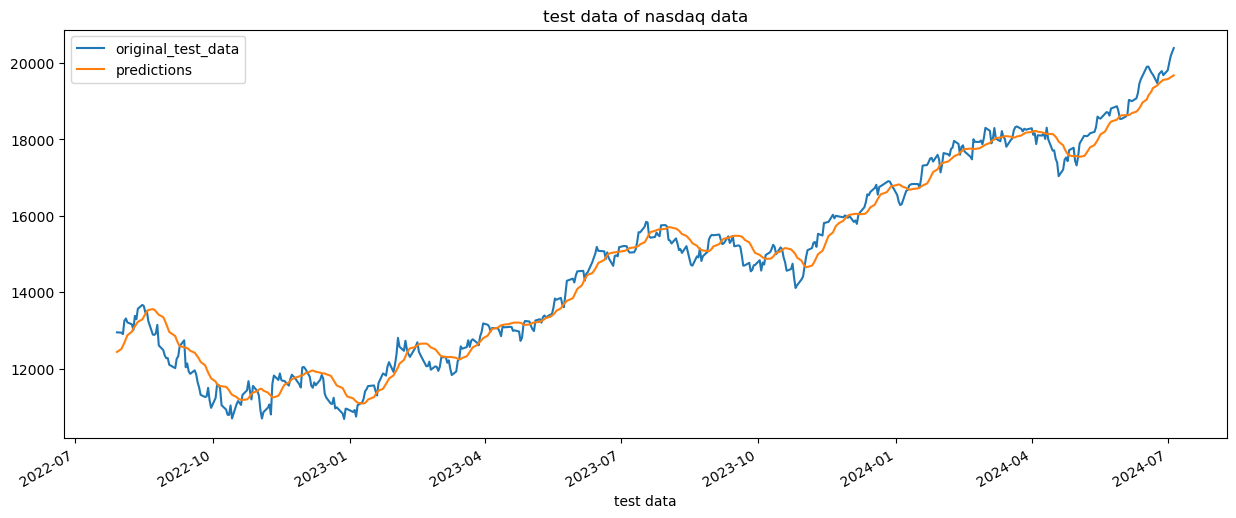

In [221]:
#Plot original test data against predictions
plot_graph((15,6), plotting_data, 'test data')

<Figure size 640x480 with 0 Axes>

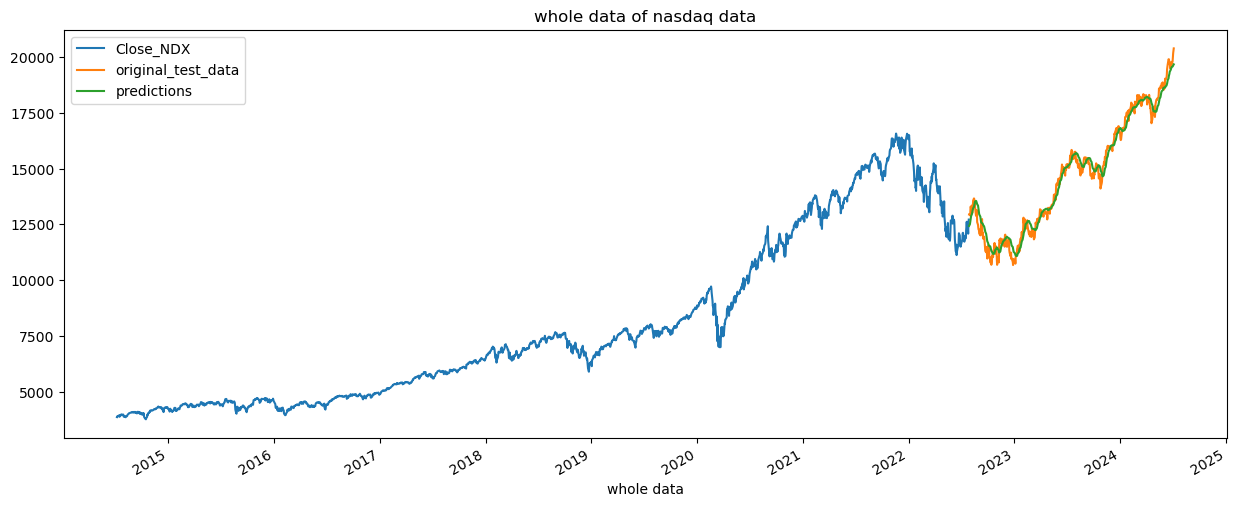

In [222]:
#ploting closing price, original test and predictions
plot_graph((15,6), pd.concat([close_price[:len_split+100], plotting_data] , axis=0), 'whole data')

In [223]:
#Save the model
model.save("Latest_stock_price_model.keras")

## Random Classifer model: This will help to see whether a stock price will go up or down

<Axes: xlabel='Price_Ticker_Date'>

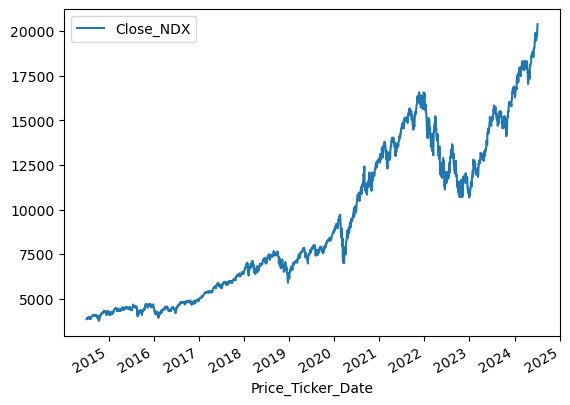

In [224]:
#Visualize closing price
nasdaq1=nasdaq.copy()
nasdaq1.plot.line(y="Close_NDX", use_index=True)

In [225]:
#Shifts to find tomorrow
nasdaq1["Tomorrow"] = nasdaq1[("Close_NDX")].shift(-1)

In [226]:
#Set target column
nasdaq1["Target"] = (nasdaq1["Tomorrow"] > nasdaq1[("Close_NDX")]).astype(int)

In [227]:
nasdaq

,Close_NDX,High_NDX,Low_NDX,Open_NDX,Year,Daily Return,Month,MA_for_250_days,MA_for_100_days,percentage_change_cp
Price_Ticker_Date,,,,,,,,,,
2014-07-08,3864.07,3903.37,3906.22,3848.18,2014,-0.740834,7,4224.12568,4023.3043,NaN
2014-07-09,3892.91,3873.17,3896.38,3863.20,2014,0.331698,7,4226.86436,4027.5459,0.007464
2014-07-10,3880.04,3837.29,3895.72,3837.16,2014,-0.628493,7,4229.39112,4031.7967,-0.003306
2014-07-11,3904.58,3888.76,3905.40,3879.40,2014,-0.633166,7,4231.92700,4036.1762,0.006325
2014-07-14,3929.46,3923.60,3937.73,3916.52,2014,0.383451,7,4234.24580,4040.5082,0.006372
...,...,...,...,...,...,...,...,...,...,...
2024-06-28,19682.87,19817.00,20017.71,19665.85,2024,-0.652880,6,NaN,NaN,-0.005365
2024-07-01,19812.22,19720.11,19827.75,19577.54,2024,-0.997757,7,NaN,NaN,0.006572
2024-07-02,20011.89,19746.22,20014.92,19741.81,2024,-0.865622,7,NaN,NaN,0.010078


In [228]:
#Import and model structure
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = nasdaq1.iloc[:-100]
test = nasdaq1.iloc[-100:]

predictors = ["Close_NDX", "Open_NDX", "High_NDX", "Low_NDX"]
model2.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [229]:
#Evaluate the model
from sklearn.metrics import precision_score

preds = model2.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test["Target"], preds)

0.55

<Axes: xlabel='Price_Ticker_Date'>

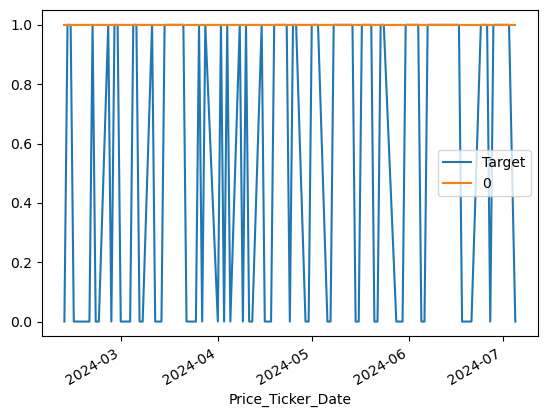

In [230]:
#Visualize target
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [231]:
#Function for predict
def predict(train, test, predictors, model):
    model2.fit(train[predictors], train["Target"])
    preds = model2.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [232]:
#Functions for backtest
def backtest(data, model2, predictors, start=500, step=50):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions)

In [233]:
#Predictions
predictions = backtest(nasdaq1, model2, predictors)

In [234]:
#Check predictions
predictions["Predictions"].value_counts()

Predictions
1    1074
0     954
Name: count, dtype: int64

In [235]:
#Measure of quality
precision_score(predictions["Target"], predictions["Predictions"])

0.5716945996275605

In [236]:
#value counts
predictions["Target"].value_counts() / predictions.shape[0]

Target
1    0.564103
0    0.435897
Name: count, dtype: float64

In [237]:
horizons = [2,5,60,250,500]
new_predictors = []

for horizon in horizons:
    rolling_averages = nasdaq1.rolling(horizon).mean()
    
    ratio_column = f"Close_Ratio_{horizon}"
    nasdaq1[ratio_column] = nasdaq1["Close_NDX"] / rolling_averages["Close_NDX"]
    
    trend_column = f"Trend_{horizon}"
    nasdaq1[trend_column] = nasdaq1.shift(1).rolling(horizon).sum()["Target"]
    
    new_predictors+= [ratio_column, trend_column]

In [238]:
nasdaq1 = nasdaq1.dropna(subset=nasdaq1.columns[nasdaq1.columns != "Tomorrow"])

In [239]:
#Create model structure
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [240]:
#Predict function
def predict(train, test, predictors, model2):
    model2.fit(train[predictors], train["Target"])
    preds = model2.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [241]:
predictions = backtest(nasdaq1, model2, new_predictors)

In [242]:
predictions["Predictions"].value_counts()

Predictions
0.0    942
1.0    337
Name: count, dtype: int64

In [243]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5400593471810089

In [244]:
predictions["Target"].value_counts() / predictions.shape[0]

Target
1    0.553557
0    0.446443
Name: count, dtype: float64

In [245]:
predictions

,Target,Predictions
Price_Ticker_Date,,
2018-06-08,1,0.0
2018-06-11,1,0.0
2018-06-12,0,0.0
2018-06-13,1,0.0
2018-06-14,0,0.0
...,...,...
2023-07-03,0,0.0
2023-07-05,0,1.0
2023-07-06,0,0.0
